# Chapter 3 — Statistical Experiments and Significance Testing

**Practical Statistics for Data Scientists — Peter Bruce, Andrew Bruce, Peter Gedeck**

Notebook ini merupakan reproduksi dan *theoretical deep-dive* Bab 3. Struktur mengikuti notebook teman sebagai acuan: eksperimen A/B, hypothesis testing, permutation test, p-value, t-test, multiple testing, degrees of freedom, ANOVA, chi-square, multi-arm bandit, serta power dan sample size.

## Tujuan
- memahami A/B testing dan perbandingan dua kelompok;
- memahami null hypothesis dan alternative hypothesis;
- menggunakan permutation test;
- memahami p-value, alpha, Type I dan Type II error;
- menggunakan t-test;
- memahami multiple testing dan degrees of freedom;
- memahami ANOVA dan F-statistic;
- memahami chi-square test;
- memahami multi-arm bandit;
- menghubungkan power dengan sample size.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

pd.set_option("display.precision", 4)

DATA_URL = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"
rng = np.random.default_rng(42)


## 1. A/B Testing

**A/B testing** membandingkan dua perlakuan atau versi, misalnya Page A dan Page B. Tujuannya bukan hanya melihat perbedaan rata-rata, tetapi menilai apakah perbedaan tersebut cukup besar dibandingkan variasi acak.

Pada contoh ini, variabel yang diamati adalah waktu kunjungan (*session time*).


In [ ]:
web_page_data = pd.read_csv(DATA_URL + "web_page_data.csv")
web_page_data.head()


,Page,Time
0,Page A,0.21
1,Page B,2.53
2,Page A,0.35
3,Page B,0.71
4,Page A,0.67


In [ ]:
summary_ab = web_page_data.groupby("Page")["Time"].agg(["count", "mean", "std"])
summary_ab


,count,mean,std
Page,,,
Page A,21,1.2633,0.8846
Page B,15,1.6200,1.0114


In [ ]:
time_a = web_page_data.loc[web_page_data["Page"] == "Page A", "Time"]
time_b = web_page_data.loc[web_page_data["Page"] == "Page B", "Time"]

observed_diff = time_b.mean() - time_a.mean()

print(f"Mean Page A : {time_a.mean():.4f}")
print(f"Mean Page B : {time_b.mean():.4f}")
print(f"Observed difference (B - A): {observed_diff:.4f}")


Mean Page A : 1.2633
Mean Page B : 1.6200
Observed difference (B - A): 0.3567


### Interpretasi awal

Perbedaan mean merupakan **observed effect**. Pada tahap ini kita belum menyatakan bahwa perbedaan tersebut benar-benar berasal dari perlakuan. Selanjutnya perbedaan dibandingkan dengan variasi yang dapat terjadi jika tidak ada efek nyata.


## 2. Hypothesis Tests

Uji hipotesis menggunakan:
- **H₀ (null hypothesis):** tidak ada perbedaan/efek;
- **H₁ (alternative hypothesis):** terdapat perbedaan/efek;
- **test statistic:** ukuran numerik yang digunakan untuk mengukur efek.

Dalam A/B testing, H₀ berarti hasil Page A dan Page B dapat dianggap berasal dari kondisi yang sama dan perbedaan yang terlihat dapat muncul karena random variation.


## 3. Resampling — Permutation Test

Permutation test membentuk **reference distribution** dengan mengacak kembali label kelompok.

Langkah:
1. gabungkan data A dan B;
2. acak data;
3. bagi kembali sesuai ukuran kelompok;
4. hitung selisih mean;
5. ulangi berkali-kali;
6. bandingkan observed difference dengan permutation distribution.


In [ ]:
combined = np.concatenate([time_a.values, time_b.values])
n_a = len(time_a)
n_b = len(time_b)

permutation_diffs = []

for _ in range(10000):
    shuffled = rng.permutation(combined)
    perm_a = shuffled[:n_a]
    perm_b = shuffled[n_a:n_a+n_b]
    permutation_diffs.append(perm_b.mean() - perm_a.mean())

permutation_diffs = np.array(permutation_diffs)

print(f"Observed difference : {observed_diff:.4f}")
print(f"Permutation mean    : {permutation_diffs.mean():.4f}")


Observed difference : 0.3567
Permutation mean    : 0.0048


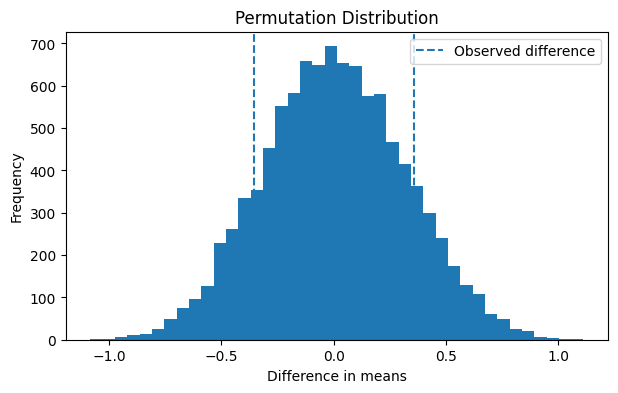

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(permutation_diffs, bins=40)
plt.axvline(observed_diff, linestyle="--", label="Observed difference")
plt.axvline(-observed_diff, linestyle="--")
plt.xlabel("Difference in means")
plt.ylabel("Frequency")
plt.title("Permutation Distribution")
plt.legend()
plt.show()


## 4. Statistical Significance dan p-Value

**p-value** menunjukkan seberapa sering statistik yang sama ekstremnya dengan hasil observasi muncul dalam reference distribution berdasarkan H₀.

Untuk uji dua arah:

**p-value = proporsi hasil permutasi dengan |difference| ≥ |observed difference|**

**Alpha (α)** adalah significance level yang ditentukan sebelum pengujian. Nilai yang umum digunakan adalah 0,05.

P-value bukan probabilitas bahwa H₀ benar.


In [ ]:
p_value = np.mean(np.abs(permutation_diffs) >= abs(observed_diff))

print(f"Permutation p-value : {p_value:.4f}")
print(f"Alpha               : {0.05:.2f}")


Permutation p-value : 0.2687
Alpha               : 0.05


### Type I dan Type II Error

- **Type I error:** menolak H₀ padahal H₀ benar.
- **Type II error:** tidak menolak H₀ padahal terdapat efek yang sebenarnya.

Karena itu, keputusan statistik perlu mempertimbangkan konteks eksperimen dan bukan hanya satu angka p-value.


## 5. t-Tests

**t-test** merupakan pendekatan parametrik untuk menguji perbedaan rata-rata.

Untuk dua kelompok independen, digunakan `scipy.stats.ttest_ind`. Contoh berikut memakai **Welch's t-test** dengan `equal_var=False`, sehingga tidak mengharuskan kedua kelompok mempunyai varians yang sama.


In [ ]:
welch_result = stats.ttest_ind(
    time_a,
    time_b,
    equal_var=False
)

print(f"t-statistic      : {welch_result.statistic:.4f}")
print(f"two-sided p-value: {welch_result.pvalue:.4f}")


t-statistic      : -1.0983
two-sided p-value: 0.2815


## 6. Multiple Testing

Ketika banyak hipotesis diuji sekaligus, peluang mendapatkan hasil yang tampak signifikan hanya karena kebetulan meningkat.

Salah satu pendekatan sederhana adalah **Bonferroni correction**:

`adjusted alpha = alpha / jumlah pengujian`


In [ ]:
alpha_awal = 0.05
jumlah_uji = 20
alpha_bonferroni = alpha_awal / jumlah_uji

print(f"Alpha awal      : {alpha_awal}")
print(f"Jumlah pengujian: {jumlah_uji}")
print(f"Adjusted alpha  : {alpha_bonferroni:.4f}")


Alpha awal      : 0.05
Jumlah pengujian: 20
Adjusted alpha  : 0.0025


## 7. Degrees of Freedom

**Degrees of freedom (df)** menunjukkan jumlah nilai yang secara efektif masih dapat berubah setelah sejumlah batasan atau parameter telah ditentukan.

Dalam prosedur statistik, bentuk reference distribution dapat bergantung pada df. Pada Welch's t-test, misalnya, df disesuaikan berdasarkan ukuran dan varians kedua kelompok.


In [ ]:
# Degrees of freedom Welch's t-test
df_welch = welch_result.df
print(f"Welch degrees of freedom: {df_welch:.4f}")


Welch degrees of freedom: 27.6934


## 8. ANOVA

**Analysis of Variance (ANOVA)** digunakan ketika terdapat lebih dari dua kelompok dan ingin diuji apakah terdapat perbedaan rata-rata.

ANOVA menggunakan **F-statistic**, yang membandingkan variasi antar-kelompok dengan variasi di dalam kelompok.

H₀ pada one-way ANOVA menyatakan bahwa mean populasi semua kelompok sama.


In [ ]:
four_sessions = pd.read_csv(DATA_URL + "four_sessions.csv")
four_sessions.head()


,Page,Time
0,Page 1,164
1,Page 2,178
2,Page 3,175
3,Page 4,155
4,Page 1,172


In [ ]:
four_sessions.groupby("Page")["Time"].agg(["count", "mean", "std"])


,count,mean,std
Page,,,
Page 1,5,172.8,14.7547
Page 2,5,182.6,5.6833
Page 3,5,175.6,10.9909
Page 4,5,164.6,5.8138


In [ ]:
groups = [
    group["Time"].values
    for _, group in four_sessions.groupby("Page")
]

anova_result = stats.f_oneway(*groups)

print(f"F-statistic : {anova_result.statistic:.4f}")
print(f"p-value     : {anova_result.pvalue:.4f}")


F-statistic : 2.7398
p-value     : 0.0776


### Resampling untuk ANOVA

Selain ANOVA parametrik, resampling dapat digunakan untuk membentuk reference distribution secara empiris. Data dikocok dengan mempertahankan ukuran masing-masing kelompok, lalu statistik antar-kelompok dihitung berulang kali.


In [ ]:
def anova_statistic(df, group_col, value_col):
    grouped = [
        g[value_col].values
        for _, g in df.groupby(group_col)
    ]
    return stats.f_oneway(*grouped).statistic

observed_f = anova_statistic(four_sessions, "Page", "Time")
print(f"Observed F-statistic: {observed_f:.4f}")


Observed F-statistic: 2.7398


## 9. Chi-Square Test

Chi-square test digunakan untuk data berbentuk **count/frequency** dan untuk mengevaluasi apakah pola kategori yang diamati konsisten dengan expectation tertentu.

Dalam contingency table, chi-square statistic mengukur seberapa jauh observed counts menyimpang dari expected counts berdasarkan asumsi independensi.


In [ ]:
click_rates = pd.read_csv(DATA_URL + "click_rates.csv")
click_rates


,Headline,Click,Rate
0,Headline A,Click,14
1,Headline A,No-click,986
2,Headline B,Click,8
3,Headline B,No-click,992
4,Headline C,Click,12
5,Headline C,No-click,988


In [ ]:
contingency = click_rates.pivot(
    index="Headline",
    columns="Click",
    values="Rate"
)

contingency


Click,Click,No-click
Headline,,
Headline A,14,986
Headline B,8,992
Headline C,12,988


In [ ]:
chi2_stat, chi2_p, chi2_df, expected = stats.chi2_contingency(
    contingency,
    correction=False
)

expected_table = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom  : {chi2_df}")
print(f"p-value             : {chi2_p:.4f}")
print("\nExpected table:")
display(expected_table)


Chi-square statistic: 1.6659
Degrees of freedom  : 2
p-value             : 0.4348

Expected table:


Click,Click,No-click
Headline,,
Headline A,11.3333,988.6667
Headline B,11.3333,988.6667
Headline C,11.3333,988.6667


**Catatan:** dataset `click_rates.csv` pada notebook acuan berisi nilai rate/count yang digunakan untuk contoh contingency table. Chi-square klasik menggunakan observed counts dan expected counts sebagai dasar perhitungan.


## 10. Multi-Arm Bandit Algorithm

**Multi-arm bandit** adalah pendekatan eksperimen dengan beberapa pilihan (*arms*) yang digunakan secara adaptif.

Dua aktivitas utamanya:
- **Exploration:** mencoba pilihan yang belum banyak diketahui;
- **Exploitation:** lebih sering memilih pilihan yang sementara memberikan reward lebih tinggi.

Contoh berikut menggunakan strategi sederhana **epsilon-greedy**.


In [ ]:
true_probabilities = np.array([0.20, 0.04, 0.08])
arms = ["A", "B", "C"]

epsilon = 0.10
trials = np.zeros(3, dtype=int)
rewards = np.zeros(3, dtype=int)

for _ in range(2000):
    if rng.random() < epsilon or trials.sum() == 0:
        arm = rng.integers(0, 3)
    else:
        observed_rates = np.divide(
            rewards,
            trials,
            out=np.zeros(3, dtype=float),
            where=trials > 0
        )
        arm = np.argmax(observed_rates)

    reward = rng.random() < true_probabilities[arm]
    trials[arm] += 1
    rewards[arm] += int(reward)

bandit_result = pd.DataFrame({
    "Arm": arms,
    "True probability": true_probabilities,
    "Trials": trials,
    "Observed reward rate": rewards / trials
})

bandit_result


,Arm,True probability,Trials,Observed reward rate
0,A,0.20,1878,0.2050
1,B,0.04,61,0.0328
2,C,0.08,61,0.1311


## 11. Power and Sample Size

**Statistical power** adalah probabilitas untuk mendeteksi efek tertentu ketika efek tersebut memang ada sesuai asumsi yang digunakan.

Sample size, effect size, alpha, dan power saling berhubungan. Secara umum, mendeteksi perbedaan yang sangat kecil membutuhkan lebih banyak observasi dibandingkan mendeteksi perbedaan yang lebih besar.


In [ ]:
power_analysis = NormalIndPower()

p_control = 0.10
p_treatment = 0.11

effect_small = proportion_effectsize(
    p_control,
    p_treatment
)

n_small = power_analysis.solve_power(
    effect_size=effect_small,
    alpha=0.05,
    power=0.80,
    alternative="two-sided"
)

print(f"Effect size (10% -> 11%): {effect_small:.4f}")
print(f"Estimated sample size per group: {np.ceil(n_small):.0f}")


Effect size (10% -> 11%): -0.0326
Estimated sample size per group: 14745


In [ ]:
p_control = 0.10
p_treatment = 0.15

effect_larger = proportion_effectsize(
    p_control,
    p_treatment
)

n_larger = power_analysis.solve_power(
    effect_size=effect_larger,
    alpha=0.05,
    power=0.80,
    alternative="two-sided"
)

print(f"Effect size (10% -> 15%): {effect_larger:.4f}")
print(f"Estimated sample size per group: {np.ceil(n_larger):.0f}")


Effect size (10% -> 15%): -0.1519
Estimated sample size per group: 681


### Interpretasi

Perbedaan 10% menjadi 11% merupakan efek yang relatif kecil sehingga kebutuhan sample size lebih besar. Ketika perbedaan yang ingin dideteksi menjadi lebih besar, kebutuhan sample size per kelompok menjadi lebih kecil dengan asumsi alpha dan power tetap.


# Poin-Poin Penting Bab 3

- A/B testing membandingkan hasil dari dua treatment atau kelompok.
- Hypothesis testing menggunakan null hypothesis, alternative hypothesis, dan test statistic.
- Permutation test membangun reference distribution dengan mengacak kembali data.
- p-value menunjukkan seberapa ekstrem hasil observasi dibandingkan reference distribution di bawah H₀.
- Alpha merupakan significance level yang ditentukan untuk pengujian.
- Type I dan Type II error merupakan dua jenis kesalahan dalam keputusan statistik.
- t-test merupakan pendekatan umum untuk membandingkan rata-rata dua kelompok.
- Multiple testing perlu diperhatikan ketika banyak hipotesis diuji.
- ANOVA digunakan untuk membandingkan lebih dari dua kelompok melalui F-statistic.
- Chi-square test digunakan untuk mengevaluasi penyimpangan count/kategori dari expectation.
- Multi-arm bandit menggabungkan eksplorasi dan eksploitasi dalam eksperimen.
- Power dan sample size membantu merancang eksperimen sebelum data dikumpulkan.

## Kesimpulan

Bab 3 menunjukkan bahwa pengujian statistik tidak hanya membandingkan angka rata-rata. Kita perlu menentukan hipotesis, memahami variasi acak, memilih metode pengujian yang sesuai, dan mempertimbangkan ketidakpastian hasil.


## Referensi Utama

Bruce, P., Bruce, A., & Gedeck, P. *Practical Statistics for Data Scientists*, 2nd ed. O'Reilly Media.

Notebook acuan: Chapter 3 dari repository teman yang diberikan.  
Dataset: repository data pendamping *Practical Statistics for Data Scientists*.
